In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score

from mlxtend.frequent_patterns import apriori, association_rules

import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [41]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings("ignore")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/dataset.csv")
import warnings
warnings.filterwarnings("ignore")

In [42]:
# Preview
df.head()
import warnings
warnings.filterwarnings("ignore")

In [39]:
df.columns
df.head()
import warnings
warnings.filterwarnings("ignore")

In [43]:
type(df['ecg_pulses'].iloc[0])
import warnings
warnings.filterwarnings("ignore")

In [9]:
import ast
import numpy as np
import pandas as pd

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [38]:
# Remove duplicates
df = df.drop_duplicates(subset=['_id'])

# Remove rows missing essential fields
df = df.dropna(subset=['ecg_pulses', 'age', 'weight'])

import warnings
warnings.filterwarnings("ignore")

In [37]:
import ast
import numpy as np

def safe_literal_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    elif isinstance(x, list):
        return x
    else:
        return []

df['ecg_pulses'] = df['ecg_pulses'].apply(safe_literal_eval)
df['segments_br'] = df['segments_br'].apply(safe_literal_eval)
df['segments_hr'] = df['segments_hr'].apply(safe_literal_eval)
import warnings
warnings.filterwarnings("ignore")

In [36]:
def compute_hrv(pulses):
    if len(pulses) > 1:
        intervals = np.diff(pulses)
        return np.std(intervals)
    return np.nan

def compute_mean_rr(pulses):
    if len(pulses) > 1:
        intervals = np.diff(pulses)
        return np.mean(intervals)
    return np.nan

df['HRV'] = df['ecg_pulses'].apply(compute_hrv)
df['Mean_RR'] = df['ecg_pulses'].apply(compute_mean_rr)
import warnings
warnings.filterwarnings("ignore")

In [35]:
def extract_avg_from_segments(segment_list):
    if len(segment_list) > 0:
        values = [seg['value'] for seg in segment_list if 'value' in seg]
        return np.mean(values) if len(values) > 0 else np.nan
    return np.nan

df['Avg_HR'] = df['segments_hr'].apply(extract_avg_from_segments)
df['Avg_BR'] = df['segments_br'].apply(extract_avg_from_segments)
import warnings
warnings.filterwarnings("ignore")

In [34]:
df_model = df[['HRV','Mean_RR','Avg_HR','Avg_BR','age','weight']]

df_model = df_model.replace([np.inf, -np.inf], np.nan)

df_model = df_model.dropna()
import warnings
warnings.filterwarnings("ignore")


In [33]:
df_model.head()
import warnings
warnings.filterwarnings("ignore")

In [18]:
df_model.shape
import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Standardize


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

Apply KMeans

In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df_model['Cluster'] = kmeans.fit_predict(X_scaled)

In [32]:
cluster_table = df_model.groupby('Cluster').mean().round(3)
cluster_table.head()

,HRV,Mean_RR,Avg_HR,Avg_BR,age,weight,Anomaly
Cluster,,,,,,,
0,0.518,1.177,49.925,10.985,4.515,29.083,0.065
1,0.274,0.804,72.576,15.505,3.252,20.270,0.064
2,0.390,0.995,58.778,14.855,3.438,17.886,0.030


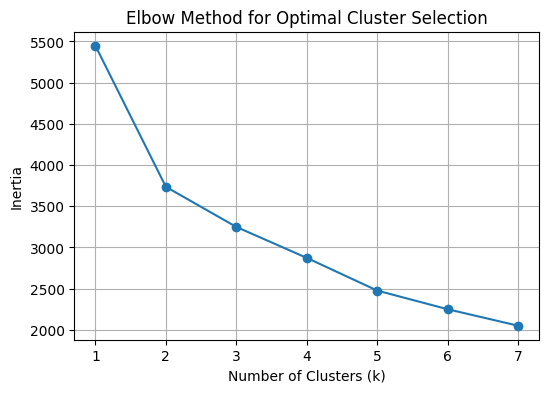

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 8):   # Try 1 to 7 clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,8), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Cluster Selection")
plt.grid(True)
plt.show()

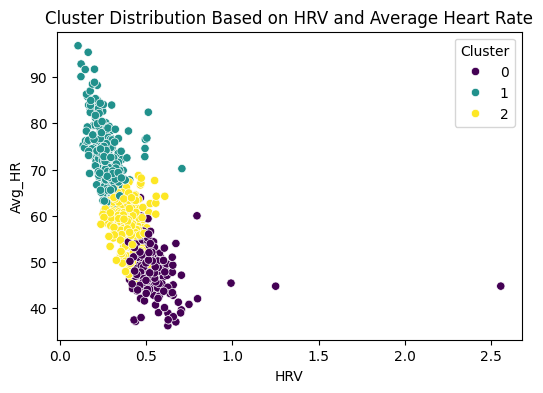

In [29]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df_model,
    x='HRV',
    y='Avg_HR',
    hue='Cluster',
    palette='viridis'
)
plt.title("Cluster Distribution Based on HRV and Average Heart Rate")
plt.show()

Anomaly Dectection

In [24]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
df_model['Anomaly'] = iso.fit_predict(X_scaled)

df_model['Anomaly'] = df_model['Anomaly'].map({1: 0, -1: 1})

df_model['Anomaly'].sum()
df_model

,HRV,Mean_RR,Avg_HR,Avg_BR,age,weight,Cluster,Anomaly
2,0.402373,1.024055,54.567273,13.545000,4.5,34.0,0,0
3,0.467617,1.089708,51.894286,13.130000,4.5,34.0,0,0
4,0.450048,0.979311,49.907500,13.990000,4.5,34.0,0,0
5,0.456805,0.991505,49.815000,9.957500,4.5,34.0,0,0
6,0.410700,1.126792,53.438519,14.500000,4.5,34.0,0,0
...,...,...,...,...,...,...,...,...
1053,0.450097,1.359347,43.960741,18.730000,3.5,25.0,0,0
1055,0.418305,1.297341,45.280000,17.845000,3.5,25.0,0,0
1058,0.568502,1.420844,42.145556,11.164615,3.5,25.0,0,0
1059,0.499741,1.382802,43.223182,11.943500,3.5,25.0,0,0
